In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import glob
import math
import re
import matplotlib.pyplot as plt
from Clustering_Functions import *

In [8]:
def Avg_bal_len_dif(C):
    return sum([len(ballot)*C[ballot] for ballot in C.keys()])/sum(C.values())

In [9]:
filename_list = glob.glob("scot-elex/**/*.csv")

In [ ]:
df = pd.DataFrame(columns=['num_cands', 'A','B','H'])

for filename in filename_list:
    print(filename)
    num_cands, election, cand_names, location = csv_parse(filename)
    party_list = party_abrevs(cand_names)
    CA = kmeans(election, proxy='Borda', borda_style='avg')
    CP = kmeans(election, proxy = 'Borda', borda_style='pes')
    CH = kmeans(election, proxy='HH')
    DA = np.abs(Avg_bal_len_dif(CA[0])-Avg_bal_len_dif(CA[1]))
    DP = np.abs(Avg_bal_len_dif(CP[0])-Avg_bal_len_dif(CP[1]))
    DH = np.abs(Avg_bal_len_dif(CH[0])-Avg_bal_len_dif(CH[1]))
    row_num = df.shape[0]
    df.loc[row_num] = [num_cands, DA, DP, DH]

In [12]:
df.to_pickle('test.pkl')

In [13]:
print(f"A = {round(df['A'].mean(),2)}, B = {round(df['B'].mean(),2)}, H = {round(df['H'].mean(),2)}.")    

A = 0.56, B = 0.59, H = 0.56.


(-0.09770529264262609, 2.053119143449051) (-0.1020366727263205, 2.1632328641437852)


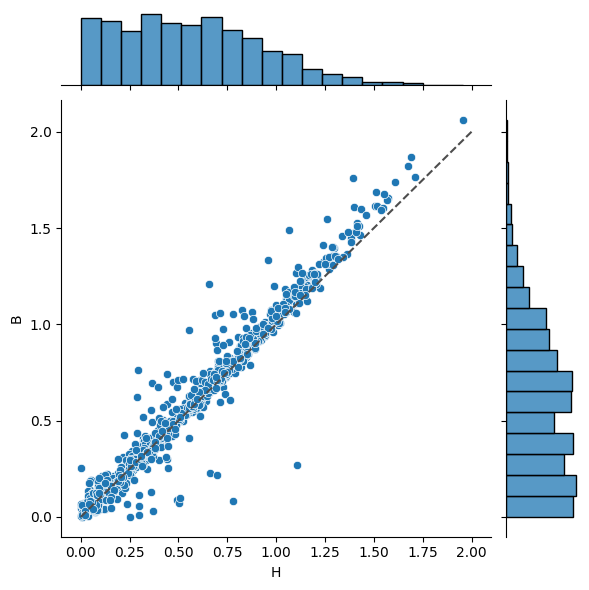

In [18]:
fig = sns.jointplot(df, x='H', y='B')
ax = fig.ax_joint
print(ax.get_xlim(), ax.get_ylim())
ax.plot((0,2), (0,2), ls="--", c=".3")
plt.show()

In [19]:
len(df)

1070

In [20]:
len(df[df['B']<df['H']])

288